# Using models trained in the Mycol app

This notebook demonstrates how to use the Cellpose and DenseNet models trained in Mycol. For accurate
segmentation and classification, it is important that the preprocessing pipelines used within the app
are used.

Everything it needs is inside `example_session.zip` at the repo root - an example session exported
from the app. Run with the `mycol_colonies_env` kernel.

In [1]:
import sys
import zipfile
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image

sys.path.insert(0, "..")

from cellpose import models as cp_models
from src.helpers.cellpose_functions import preprocess_for_cellpose, convert_cellpose_mask_to_single_array
from src.helpers.densenet_functions import (
    get_device,
    build_densenet,
    generate_patches_with_ids,
    patch_to_tensor,
    imagenet_normalize,
)

# --- paths & config ---
# Everything comes out of example_session.zip, a session exported from the app.
# Cellpose needs a real path to its checkpoint, so the members used here are
# unpacked once into a scratch folder beside this notebook.
session_zip = Path("../example_session.zip")
session_dir = Path("example_session")
needed = ["images/image_01.tif", "cellpose_model.pt",
          "densenet_model.pth", "densenet_class_map.csv"]

with zipfile.ZipFile(session_zip) as z:
    for member in needed:
        if not (session_dir / member).exists():
            z.extract(member, session_dir)

image_path = session_dir / "images" / "image_01.tif"
cellpose_model_path = session_dir / "cellpose_model.pt"
densenet_model_path = session_dir / "densenet_model.pth"

# Class order is read from the session rather than assumed: the DenseNet outputs an
# index, and this is the mapping the app trained it with.
class_names = (pd.read_csv(session_dir / "densenet_class_map.csv")
                 .sort_values("class_index")["class_name"].tolist())

print(f"image    {image_path}")
print(f"classes  {class_names}")

image    example_session/images/image_01.tif
classes  ['Germinated', 'Ungerminated']


In [ ]:
# --- load image ---
# add_image() is how a picture enters the app, and its output is the only form the
# rest of the pipeline sees: PIL to RGB, uint8. 
raw = np.array(Image.open(image_path).convert("RGB"), dtype=np.uint8)
H, W = raw.shape[:2]
rec = {"image": raw, "H": H, "W": W}  # record dict used throughout the app

# --- segment ---
cp_model = cp_models.CellposeModel(pretrained_model=str(cellpose_model_path),
                                   gpu=torch.cuda.is_available())
# preprocess_for_cellpose: converts to grayscale, matching exactly what the app does
masks_raw, _, _ = cp_model.eval(preprocess_for_cellpose(rec), diameter=0, channels=[0, 0])
# convert_cellpose_mask_to_single_array: remaps instance IDs to a contiguous label image (1..N)
masks = convert_cellpose_mask_to_single_array(masks_raw, H, W)
rec["masks"] = masks

# --- classify ---
# This mirrors classify_cells() in src/helpers/densenet_functions.py step for step.
device = get_device()
# build_densenet: constructs the same DenseNet-121 architecture used during training
# (ImageNet features frozen, two-layer classifier head on top)
dn_model = build_densenet(num_classes=len(class_names))
dn_model.load_state_dict(torch.load(densenet_model_path, map_location="cpu", weights_only=True))
dn_model.to(device).eval()

# generate_patches_with_ids: crops each cell to its bounding box, blacks out the
# background, and pads to a 64x64 square (input_size in the session's training params)
patches, cell_ids = generate_patches_with_ids(rec)
# patch_to_tensor: scales the foreground mean to 127.5, HWC -> CHW, and maps to [0, 1]
X = torch.stack([patch_to_tensor(p) for p in patches])
# imagenet_normalize: the backbone is frozen ImageNet weights and expects ImageNet statistics
X = imagenet_normalize(X).to(device)

with torch.no_grad():
    preds = torch.argmax(dn_model(X), dim=1).cpu().numpy()

cell_classes = {cid: class_names[idx] for cid, idx in zip(cell_ids, preds)}
print(f"{len(cell_classes)} cells classified")

/Users/sambra/miniforge3/envs/mycol_colonies_env/lib/python3.12/site-packages/cellpose/dynamics.py:760: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:823.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),


14 cells classified


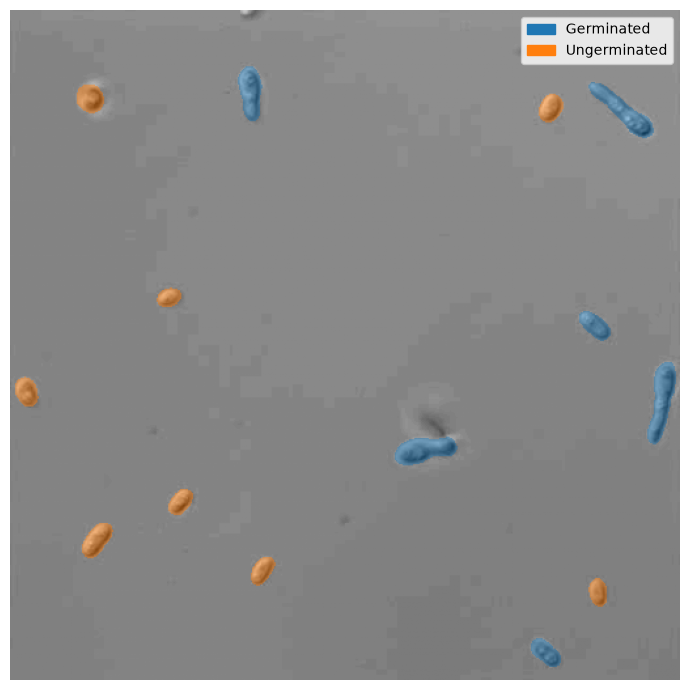

In [3]:
# --- visualise ---
colours = {name: plt.cm.tab10(i) for i, name in enumerate(class_names)}
overlay = np.zeros((H, W, 4), dtype=np.float32)
for cid, cls in cell_classes.items():
    overlay[masks == cid] = colours[cls]

base = raw if raw.ndim == 2 else raw[..., 0]
base = (base.astype(np.float32) - base.min()) / max(np.ptp(base), 1)

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(base, cmap="gray")
ax.imshow(overlay, alpha=0.5)
ax.legend(handles=[mpatches.Patch(color=c, label=n) for n, c in colours.items()], loc="upper right")
ax.axis("off")
plt.tight_layout()
plt.show()

In [4]:
# show per class cell counts

import pandas as pd

pd.Series(cell_classes.values()).value_counts().rename("count").to_frame().T

,Ungerminated,Germinated
count,8,6
